# Exploratory Data Analysis (EDA) — M5 Retail Dataset (subconjunto experimental)

Realiza el mismo análisis exploratorio que `traffic/3-eda.ipynb` pero **únicamente sobre el subconjunto de 500 series densas** utilizado en los experimentos de Chronos-2 y TimeXer.

El subconjunto se selecciona con la estrategia `dense_random` (top 25% por `nonzero_ratio`, seed=42), idéntica a la de los notebooks de experimentos.

**Target variable**: `target` (daily unit sales per item-store series).

Three processed splits are analysed:
- `m5_context.csv` — historical training window (2011-01-29 → 2016-04-24)
- `m5_future.csv` — 28-day holdout features (2016-04-25 → 2016-05-22), no `target`
- `m5_actuals.csv` — 28-day holdout ground truth (`id`, `timestamp`, `target`)

In [804]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

TITLE_PAD = 14  # distance between title and plot top edge (default matplotlib = 6)

plt.rcParams.update({
    'font.size':        14,
    'axes.titlesize':   15,
    'axes.labelsize':   14,
    'xtick.labelsize':  13,
    'ytick.labelsize':  13,
    'legend.fontsize':  14,
    'figure.titlesize': 16,
    'axes.titlepad':    TITLE_PAD,
})

# Boosted sizes for multi-subplot figures (2+ panels per row)
MULTI_RC = {
    'axes.titlesize':   20,
    'axes.labelsize':   19,
    'xtick.labelsize':  17,
    'ytick.labelsize':  17,
    'legend.fontsize':  19,
    'axes.titlepad':    TITLE_PAD,
}

## 1. Load datasets

In [768]:
DATA_DIR = 'dataset/processed'

ctx = pd.read_csv(f'{DATA_DIR}/m5_context.csv', parse_dates=['timestamp'])
fut = pd.read_csv(f'{DATA_DIR}/m5_future.csv', parse_dates=['timestamp'])
act = pd.read_csv(f'{DATA_DIR}/m5_actuals.csv', parse_dates=['timestamp'])

print('Shapes (full dataset):')
print(f'  context : {ctx.shape[0]:>12,} rows × {ctx.shape[1]} columns')
print(f'  future  : {fut.shape[0]:>12,} rows × {fut.shape[1]} columns')
print(f'  actuals : {act.shape[0]:>12,} rows × {act.shape[1]} columns')
print()
print(f'Series (context): {ctx["id"].nunique():,}')
print(f'Series (future) : {fut["id"].nunique():,}')
print(f'Series (actuals): {act["id"].nunique():,}')
print()
print(f'Context date range : {ctx["timestamp"].min().date()} → {ctx["timestamp"].max().date()}')
print(f'Future  date range : {fut["timestamp"].min().date()} → {fut["timestamp"].max().date()}')
ctx.head()

Shapes (full dataset):
  context :   58,327,370 rows × 9 columns
  future  :      853,720 rows × 8 columns
  actuals :      853,720 rows × 3 columns

Series (context): 30,490
Series (future) : 30,490
Series (actuals): 30,490

Context date range : 2011-01-29 → 2016-04-24
Future  date range : 2016-04-25 → 2016-05-22


,id,timestamp,target,sell_price,snap,wday,month,event_any,event_type_main
0,FOODS_1_001_CA_1,2011-01-29,3,2.0,0.0,1,1,0,NaN
1,FOODS_1_001_CA_1,2011-01-30,0,2.0,0.0,2,1,0,NaN
2,FOODS_1_001_CA_1,2011-01-31,0,2.0,0.0,3,1,0,NaN
3,FOODS_1_001_CA_1,2011-02-01,1,2.0,1.0,4,2,0,NaN
4,FOODS_1_001_CA_1,2011-02-02,4,2.0,1.0,5,2,0,NaN


## 2. Selección del subconjunto experimental (dense_random)

Los experimentos de Chronos-2 y TimeXer usan un subconjunto de **500 series** seleccionadas con la estrategia `dense_random`:

- Se calcula el `nonzero_ratio` (fracción de días con ventas > 0) por serie.
- Se filtra el **percentil 75** más denso (top 25%).
- Se muestrea aleatoriamente 500 series de ese pool con `seed=42`.

El fichero de IDs se carga si ya existe (generado por los notebooks de experimentos), o se genera y guarda para reproducibilidad.

In [769]:
import os

# ============================================================
# SUBSET CONFIG — debe coincidir exactamente con los notebooks
# de experimentos (Chronos-2, TimeXer)
# ============================================================
MAX_SERIES       = 500
SERIES_SELECTION = 'dense_random'
DENSE_QUANTILE   = 0.75
DENSITY_METRIC   = 'nonzero_ratio'
RANDOM_SEED      = 42

SELECTED_IDS_PATH = (
    f'{DATA_DIR}/m5_selected_ids__{SERIES_SELECTION}'
    f'__n{MAX_SERIES}'
    f'__q{int(DENSE_QUANTILE*100)}'
    f'__seed{RANDOM_SEED}.csv'
)

# ============================================================
# SERIES-LEVEL STATS
# ============================================================
series_stats_full = (
    ctx.groupby('id')
    .agg(
        total_sales=('target', 'sum'),
        mean_sales=('target', 'mean'),
        nonzero_days=('target', lambda s: int((s > 0).sum())),
        n_days=('target', 'size'),
    )
    .reset_index()
)
series_stats_full['nonzero_ratio'] = (
    series_stats_full['nonzero_days'] / series_stats_full['n_days']
)

all_ids = series_stats_full['id'].drop_duplicates().sort_values().reset_index(drop=True)

# ============================================================
# LOAD OR CREATE SUBSET IDS
# ============================================================
if os.path.exists(SELECTED_IDS_PATH):
    selected_ids = pd.read_csv(SELECTED_IDS_PATH)['id'].drop_duplicates().reset_index(drop=True)
    print(f'Loaded existing selected IDs from: {SELECTED_IDS_PATH}')
    print(f'Loaded {len(selected_ids)} series')
else:
    density_threshold = series_stats_full[DENSITY_METRIC].quantile(DENSE_QUANTILE)
    dense_pool = series_stats_full[
        series_stats_full[DENSITY_METRIC] >= density_threshold
    ].copy()

    if len(dense_pool) < MAX_SERIES:
        raise ValueError(
            f'Dense pool too small: only {len(dense_pool)} eligible series, '
            f'but MAX_SERIES={MAX_SERIES}. Lower DENSE_QUANTILE or reduce MAX_SERIES.'
        )

    selected_ids = (
        dense_pool['id']
        .sample(n=MAX_SERIES, random_state=RANDOM_SEED)
        .sort_values()
        .reset_index(drop=True)
    )

    pd.DataFrame({'id': selected_ids}).to_csv(SELECTED_IDS_PATH, index=False)
    print(f'Dense sampling using metric="{DENSITY_METRIC}"')
    print(f'Density threshold at quantile {DENSE_QUANTILE:.2f}: {density_threshold:.6f}')
    print(f'Dense pool size: {len(dense_pool)}')
    print(f'Created and saved selected IDs to: {SELECTED_IDS_PATH}')
    print(f'Saved {len(selected_ids)} series using selection="{SERIES_SELECTION}"')

# ============================================================
# FILTER ALL DATAFRAMES
# ============================================================
selected_ids_set = set(selected_ids)

ctx = ctx[ctx['id'].isin(selected_ids_set)].copy()
fut = fut[fut['id'].isin(selected_ids_set)].copy()
act = act[act['id'].isin(selected_ids_set)].copy()

ctx = ctx.sort_values(['id', 'timestamp']).reset_index(drop=True)
fut = fut.sort_values(['id', 'timestamp']).reset_index(drop=True)
act = act.sort_values(['id', 'timestamp']).reset_index(drop=True)

# ============================================================
# REPORT
# ============================================================
selected_stats = (
    series_stats_full[series_stats_full['id'].isin(selected_ids_set)]
    .sort_values('nonzero_ratio', ascending=False)
    .reset_index(drop=True)
)

print()
print('Shapes after subset filtering:')
print(f'  context : {ctx.shape[0]:>12,} rows × {ctx.shape[1]} columns')
print(f'  future  : {fut.shape[0]:>12,} rows × {fut.shape[1]} columns')
print(f'  actuals : {act.shape[0]:>12,} rows × {act.shape[1]} columns')
print()
print(f'Series (context): {ctx["id"].nunique():,}')
print(f'Series (future) : {fut["id"].nunique():,}')
print(f'Series (actuals): {act["id"].nunique():,}')
print()
print('Subset nonzero_ratio summary:')
print(selected_stats['nonzero_ratio'].describe().round(4))
print()
print('Top-10 densest series:')
display(selected_stats[['id', 'nonzero_days', 'n_days', 'nonzero_ratio', 'mean_sales', 'total_sales']].head(10))

Loaded existing selected IDs from: dataset/processed/m5_selected_ids__dense_random__n500__q75__seed42.csv
Loaded 500 series

Shapes after subset filtering:
  context :      956,500 rows × 9 columns
  future  :       14,000 rows × 8 columns
  actuals :       14,000 rows × 3 columns

Series (context): 500
Series (future) : 500
Series (actuals): 500

Subset nonzero_ratio summary:
count    500.0000
mean       0.6471
std        0.1360
min        0.4631
25%        0.5337
50%        0.6257
75%        0.7313
max        0.9963
Name: nonzero_ratio, dtype: float64

Top-10 densest series:


,id,nonzero_days,n_days,nonzero_ratio,mean_sales,total_sales
0,FOODS_3_555_CA_2,1906,1913,0.996341,16.205436,31001
1,FOODS_3_080_WI_1,1906,1913,0.996341,12.945635,24765
2,FOODS_3_694_WI_3,1906,1913,0.996341,44.763722,85633
3,FOODS_3_714_CA_3,1905,1913,0.995818,27.126503,51893
4,FOODS_3_694_WI_1,1904,1913,0.995295,21.551490,41228
5,FOODS_3_668_WI_2,1893,1913,0.989545,7.618923,14575
6,FOODS_3_714_CA_2,1890,1913,0.987977,10.853110,20762
7,FOODS_3_473_TX_3,1882,1913,0.983795,5.991636,11462
8,FOODS_3_228_TX_1,1874,1913,0.979613,6.920544,13239
9,FOODS_1_018_CA_1,1860,1913,0.972295,9.706221,18568


## 3. Imputación de sell_price y event_type_main

Los notebooks de experimentos (Chronos-2, TimeXer) aplican imputación **después** del filtrado por subconjunto y **antes** de alimentar los datos al modelo, dentro de `fill_sell_price` y `prepare_panel`. Se replica aquí para que el EDA refleje los datos tal como los ve el modelo:

**sell_price**:
1. ffill + bfill por serie → propaga el último precio conocido.
2. Mediana por serie → cubre series que arrancan con NaN.
3. Mediana global → fallback final.

**event_type_main**: NaN → `"None"` (string) — los días sin evento se codifican como la cadena `"None"`, no como valor nulo.

In [770]:
def fill_sell_price(context_df, future_df):
    context_df = context_df.copy()
    future_df = future_df.copy()

    context_df['sell_price'] = (
        context_df.groupby('id')['sell_price']
        .transform(lambda s: s.ffill().bfill())
    )

    median_price_by_id = context_df.groupby('id')['sell_price'].median()

    future_df['sell_price'] = (
        future_df.groupby('id')['sell_price']
        .transform(lambda s: s.ffill().bfill())
    )
    future_df['sell_price'] = future_df['sell_price'].fillna(
        future_df['id'].map(median_price_by_id)
    )

    global_median = context_df['sell_price'].median()
    context_df['sell_price'] = context_df['sell_price'].fillna(global_median)
    future_df['sell_price'] = future_df['sell_price'].fillna(global_median)

    return context_df, future_df

ctx, fut = fill_sell_price(ctx, fut)

# event_type_main: NaN → "None" string (matches prepare_panel in experiment notebooks)
for df in [ctx, fut, act]:
    if 'event_type_main' in df.columns:
        df['event_type_main'] = df['event_type_main'].fillna('None').astype(str)

print('Nulls after imputation:')
print(f'  ctx sell_price      : {ctx["sell_price"].isnull().sum()}')
print(f'  fut sell_price      : {fut["sell_price"].isnull().sum()}')
print(f'  ctx event_type_main : {ctx["event_type_main"].isnull().sum()}')
print(f'  fut event_type_main : {fut["event_type_main"].isnull().sum()}')
print()
print('ctx event_type_main value counts:')
print(ctx['event_type_main'].value_counts())

Nulls after imputation:
  ctx sell_price      : 0
  fut sell_price      : 0
  ctx event_type_main : 0
  fut event_type_main : 0

ctx event_type_main value counts:
event_type_main
None         879500
Religious     26000
National      25500
Cultural      17500
Sporting       8000
Name: count, dtype: int64


## 4. Basic inspection

In [771]:
ctx.dtypes

id                         object
timestamp          datetime64[ns]
target                      int64
sell_price                float64
snap                      float64
wday                        int64
month                       int64
event_any                   int64
event_type_main            object
dtype: object

In [772]:
# Column classification
TARGET     = 'target'
CONTINUOUS = ['target', 'sell_price']
BINARY     = ['snap', 'event_any']
CATEGORICAL = ['wday', 'month', 'event_type_main']
META       = ['id', 'timestamp']

# Parse hierarchical dimensions from the series ID
# Format: {category}_{dept_num}_{item_num}_{state}_{store_num}  e.g. FOODS_1_001_CA_1
def parse_id(series: pd.Series) -> pd.DataFrame:
    parts = series.str.split('_', expand=True)
    return pd.DataFrame({
        'category': parts[0],
        'dept_id' : parts[0] + '_' + parts[1],
        'state_id': parts[3],
        'store_id': parts[3] + '_' + parts[4],
    })

id_dims = parse_id(ctx['id'])
ctx = pd.concat([ctx, id_dims], axis=1)

print('Unique values per hierarchical dimension:')
for col in ['category', 'dept_id', 'state_id', 'store_id']:
    print(f'  {col:<12}: {ctx[col].nunique()} → {sorted(ctx[col].unique())}')

Unique values per hierarchical dimension:
  category    : 3 → ['FOODS', 'HOBBIES', 'HOUSEHOLD']
  dept_id     : 7 → ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']
  state_id    : 3 → ['CA', 'TX', 'WI']
  store_id    : 10 → ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']


In [773]:
# Null inspection (after imputation)
nulls = ctx.isnull().sum()
print('Null counts (context, after imputation):')
print(nulls[nulls > 0] if nulls.sum() > 0 else 'No null values found.')
print()
pct = (nulls / len(ctx) * 100).round(2)
pd.DataFrame({'nulls': nulls[nulls > 0], '% of total': pct[nulls > 0]})

Null counts (context, after imputation):
No null values found.



,nulls,% of total


In [774]:
ctx[CONTINUOUS].describe()

,target,sell_price
count,956500.000000,956500.000000
mean,3.295940,2.942764
std,6.318175,2.197572
min,0.000000,0.050000
25%,0.000000,1.480000
50%,1.000000,2.480000
75%,4.000000,3.880000
max,323.000000,15.720000


In [775]:
# Binary / flag columns
for col in BINARY:
    print(f'--- {col} ---')
    print(ctx[col].value_counts().sort_index())
    print()

# Categorical columns
for col in CATEGORICAL:
    print(f'--- {col} ---')
    print(ctx[col].value_counts().sort_index())
    print()

--- snap ---
snap
0.0    641500
1.0    315000
Name: count, dtype: int64

--- event_any ---
event_any
0    879500
1     77000
Name: count, dtype: int64

--- wday ---
wday
1    137000
2    137000
3    136500
4    136500
5    136500
6    136500
7    136500
Name: count, dtype: int64

--- month ---
month
1     79000
2     85000
3     93000
4     87000
5     77500
6     75000
7     77500
8     77500
9     75000
10    77500
11    75000
12    77500
Name: count, dtype: int64

--- event_type_main ---
event_type_main
Cultural      17500
National      25500
None         879500
Religious     26000
Sporting       8000
Name: count, dtype: int64



## 5. Target variable: `target` (daily unit sales)

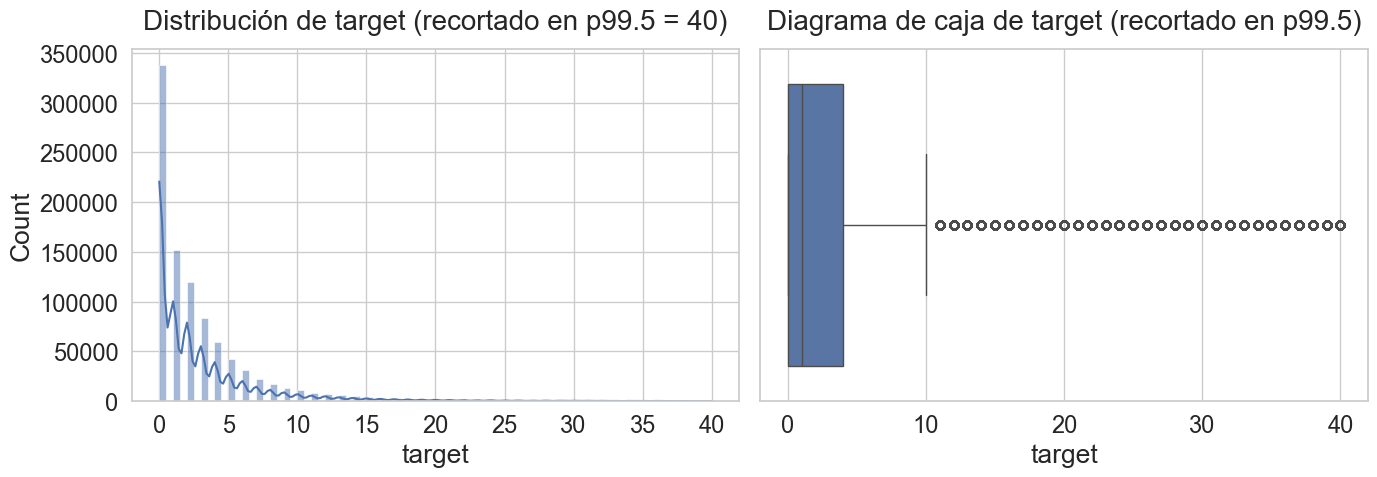

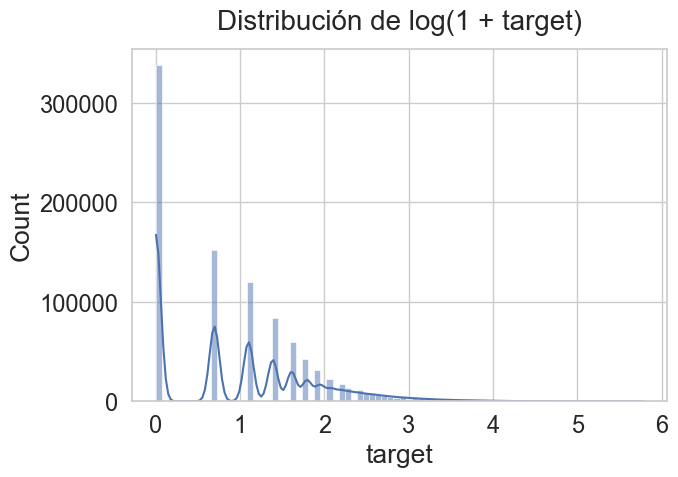

Mean   : 3.2959
Median : 1.0000
Std    : 6.3182
Max    : 323
% zeros: 35.29%  ← intermittent demand


In [805]:
from matplotlib.ticker import MultipleLocator

clip_val = ctx[TARGET].quantile(0.995)

with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(ctx.loc[ctx[TARGET] <= clip_val, TARGET], kde=True, bins=80, ax=axes[0])
    axes[0].set_title(f'Distribución de target (recortado en p99.5 = {clip_val:.0f})')
    axes[0].xaxis.set_major_locator(MultipleLocator(5))
    axes[0].yaxis.set_major_locator(MultipleLocator(50000))
    sns.boxplot(x=ctx.loc[ctx[TARGET] <= clip_val, TARGET], ax=axes[1])
    axes[1].set_title('Diagrama de caja de target (recortado en p99.5)')
    plt.tight_layout()
    plt.show()

with plt.rc_context(MULTI_RC):
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    sns.histplot(np.log1p(ctx[TARGET]), kde=True, bins=80, ax=ax)
    ax.set_title('Distribución de log(1 + target)')
    plt.tight_layout()
    plt.show()

print(f'Mean   : {ctx[TARGET].mean():.4f}')
print(f'Median : {ctx[TARGET].median():.4f}')
print(f'Std    : {ctx[TARGET].std():.4f}')
print(f'Max    : {ctx[TARGET].max()}')
print(f'% zeros: {(ctx[TARGET] == 0).mean() * 100:.2f}%  ← intermittent demand')

## 6. Sparsity analysis — intermittent demand

M5 is characterised by **intermittent demand**: many series have a high proportion of zero-sale days.
Understanding sparsity is critical for model selection and evaluation.

In [777]:
# Per-series sparsity statistics
series_stats = (
    ctx.groupby('id')[TARGET]
    .agg(
        n_days='count',
        mean_sales='mean',
        std_sales='std',
        zero_days=lambda x: (x == 0).sum(),
    )
    .assign(zero_ratio=lambda d: d['zero_days'] / d['n_days'])
    .reset_index()
)
# Merge hierarchy
series_stats = series_stats.merge(
    ctx.groupby('id')[['category', 'dept_id', 'state_id', 'store_id']].first().reset_index(),
    on='id'
)

print('Per-series sparsity summary:')
print(series_stats[['n_days', 'mean_sales', 'std_sales', 'zero_ratio']].describe().round(3))

Per-series sparsity summary:
       n_days  mean_sales  std_sales  zero_ratio
count   500.0     500.000    500.000     500.000
mean   1913.0       3.296      3.428       0.353
std       0.0       4.115      3.363       0.136
min    1913.0       0.709      0.901       0.004
25%    1913.0       1.273      1.602       0.269
50%    1913.0       1.944      2.302       0.374
75%    1913.0       3.620      3.810       0.466
max    1913.0      44.764     34.541       0.537


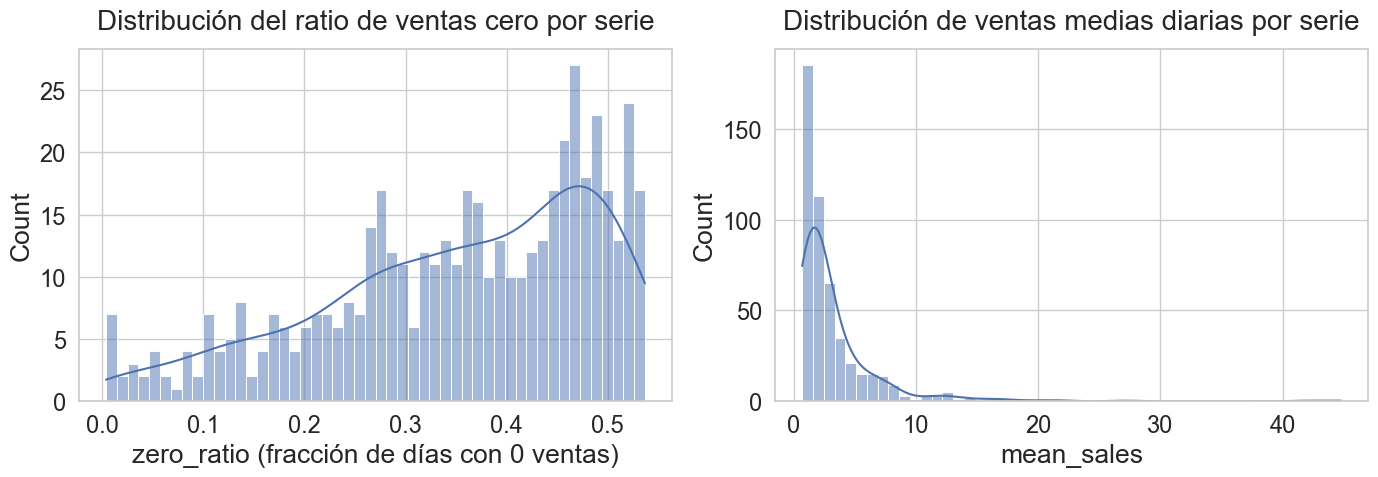

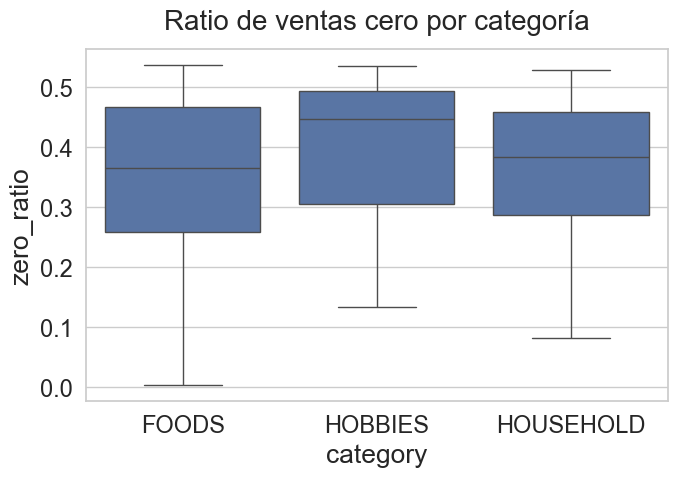


Zero-ratio thresholds:
  > 50%: 59 series (11.8%)
  > 70%: 0 series (0.0%)
  > 90%: 0 series (0.0%)


In [806]:
with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(series_stats['zero_ratio'], bins=50, kde=True, ax=axes[0])
    axes[0].set_title('Distribución del ratio de ventas cero por serie')
    axes[0].set_xlabel('zero_ratio (fracción de días con 0 ventas)')
    sns.histplot(series_stats['mean_sales'], bins=50, kde=True, ax=axes[1])
    axes[1].set_title('Distribución de ventas medias diarias por serie')
    axes[1].set_xlabel('mean_sales')
    plt.tight_layout()
    plt.show()

with plt.rc_context(MULTI_RC):
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    sns.boxplot(data=series_stats, x='category', y='zero_ratio', ax=ax)
    ax.set_title('Ratio de ventas cero por categoría')
    plt.tight_layout()
    plt.show()

print('\nZero-ratio thresholds:')
for threshold in [0.5, 0.7, 0.9]:
    n = (series_stats['zero_ratio'] > threshold).sum()
    print(f'  > {threshold:.0%}: {n:,} series ({n/len(series_stats)*100:.1f}%)')

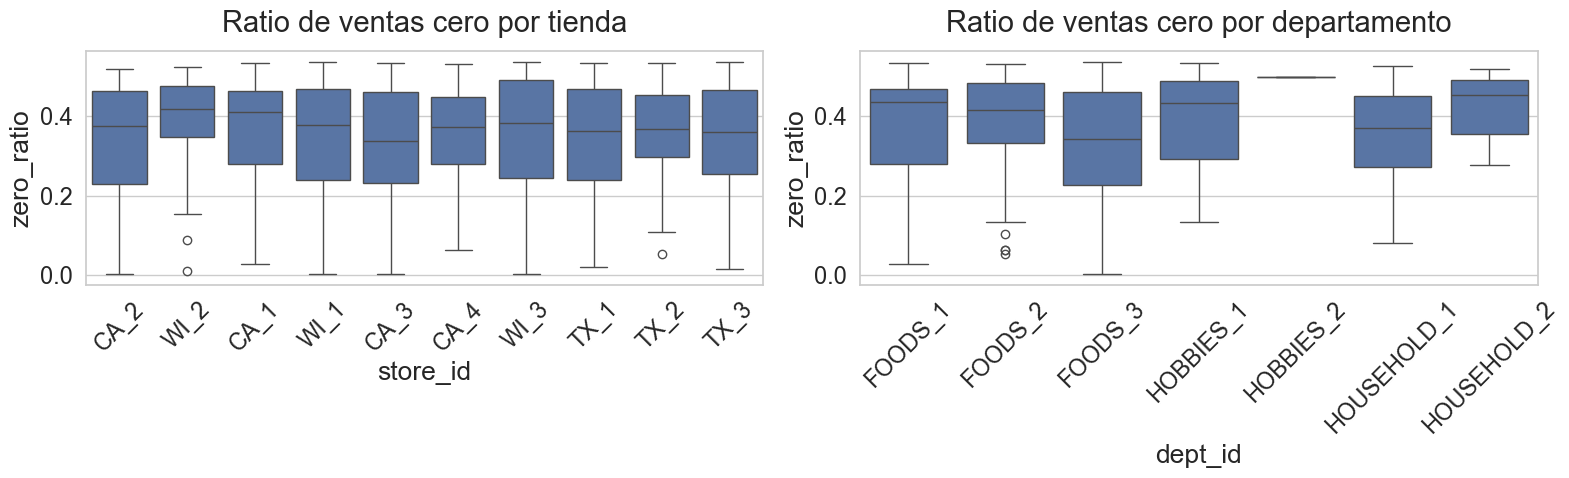

In [779]:
with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.boxplot(data=series_stats, x='store_id', y='zero_ratio', ax=axes[0])
    axes[0].set_title('Ratio de ventas cero por tienda')
    axes[0].tick_params(axis='x', rotation=45)

    sns.boxplot(data=series_stats, x='dept_id', y='zero_ratio', ax=axes[1])
    axes[1].set_title('Ratio de ventas cero por departamento')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

## 7. Distribution of continuous variables

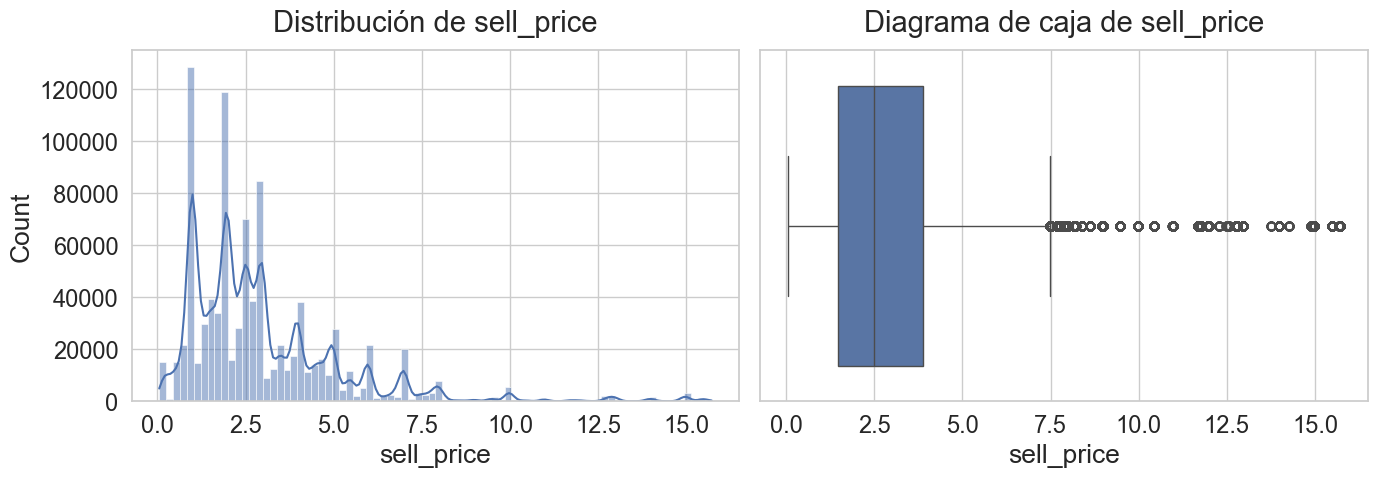

count    956500.000000
mean          2.942764
std           2.197572
min           0.050000
25%           1.480000
50%           2.480000
75%           3.880000
max          15.720000
Name: sell_price, dtype: float64

Null sell_price rows: 0  (0.00%)


In [780]:
sp = ctx['sell_price'].dropna()

with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(sp, bins=80, kde=True, ax=axes[0])
    axes[0].set_title('Distribución de sell_price')

    sns.boxplot(x=sp, ax=axes[1])
    axes[1].set_title('Diagrama de caja de sell_price')

    plt.tight_layout()
    plt.show()

print(sp.describe())
print(f'\nNull sell_price rows: {ctx["sell_price"].isnull().sum():,}  ({ctx["sell_price"].isnull().mean()*100:.2f}%)')

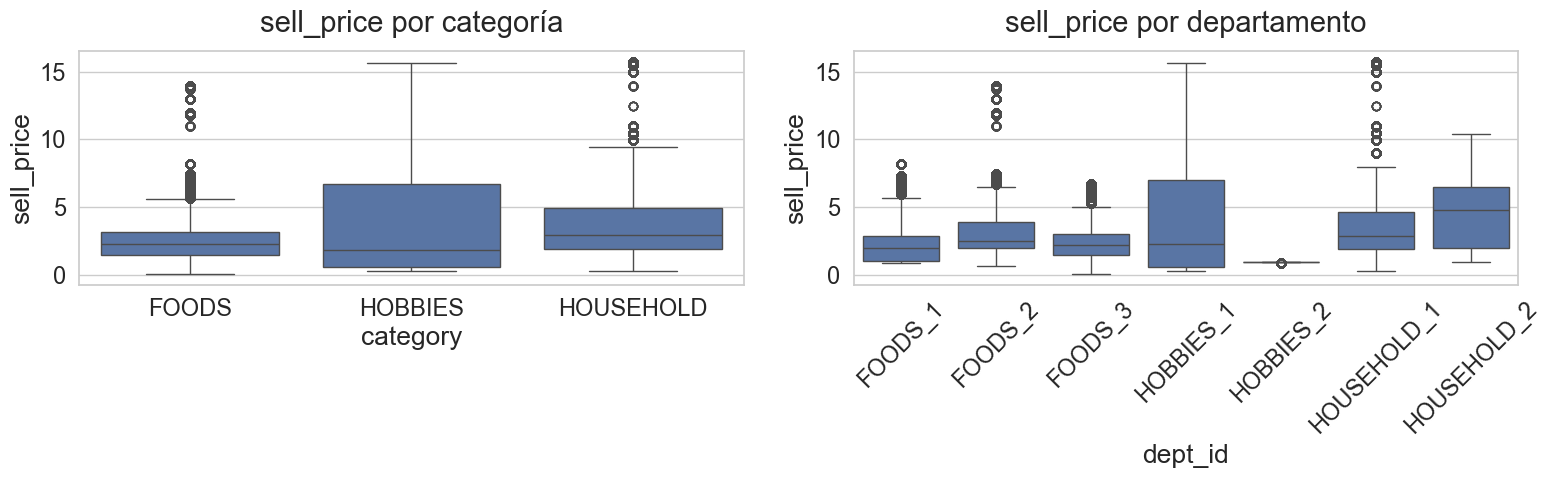

In [781]:
with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.boxplot(data=ctx.dropna(subset=['sell_price']), x='category', y='sell_price', ax=axes[0])
    axes[0].set_title('sell_price por categoría')

    sns.boxplot(data=ctx.dropna(subset=['sell_price']), x='dept_id', y='sell_price', ax=axes[1])
    axes[1].set_title('sell_price por departamento')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

## 8. Outlier detection (IQR method) — continuous variables

In [782]:
Q1 = ctx[CONTINUOUS].quantile(0.25)
Q3 = ctx[CONTINUOUS].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_counts = ((ctx[CONTINUOUS] < lower) | (ctx[CONTINUOUS] > upper)).sum()
outlier_pct = (outlier_counts / len(ctx) * 100).round(2)

pd.DataFrame({'outliers': outlier_counts, '% of total': outlier_pct})

,outliers,% of total
target,65797,6.88
sell_price,36340,3.80


## 9. Correlation analysis

### 9.1 Pearson correlation — continuous variables

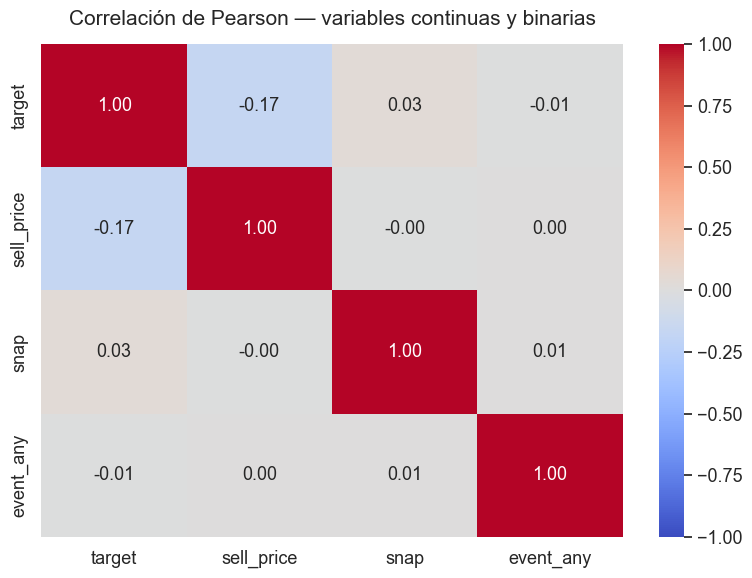

Correlation with target (abs):
sell_price    0.169083
snap          0.032586
event_any     0.006434
Name: target, dtype: float64


In [783]:
corr = ctx[CONTINUOUS + BINARY].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1,
            annot_kws={'size': 13})
plt.title('Correlación de Pearson — variables continuas y binarias')
plt.tight_layout()
plt.show()

target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print('Correlation with target (abs):')
print(target_corr)

### 9.1b Within-series correlation

The global Pearson correlation mixes **between-series** and **within-series** variance.
Since each series (`id`) has its own sales baseline, global correlations can be misleading (Simpson's paradox).
We demean by series to isolate the temporal relationships the model will actually exploit.

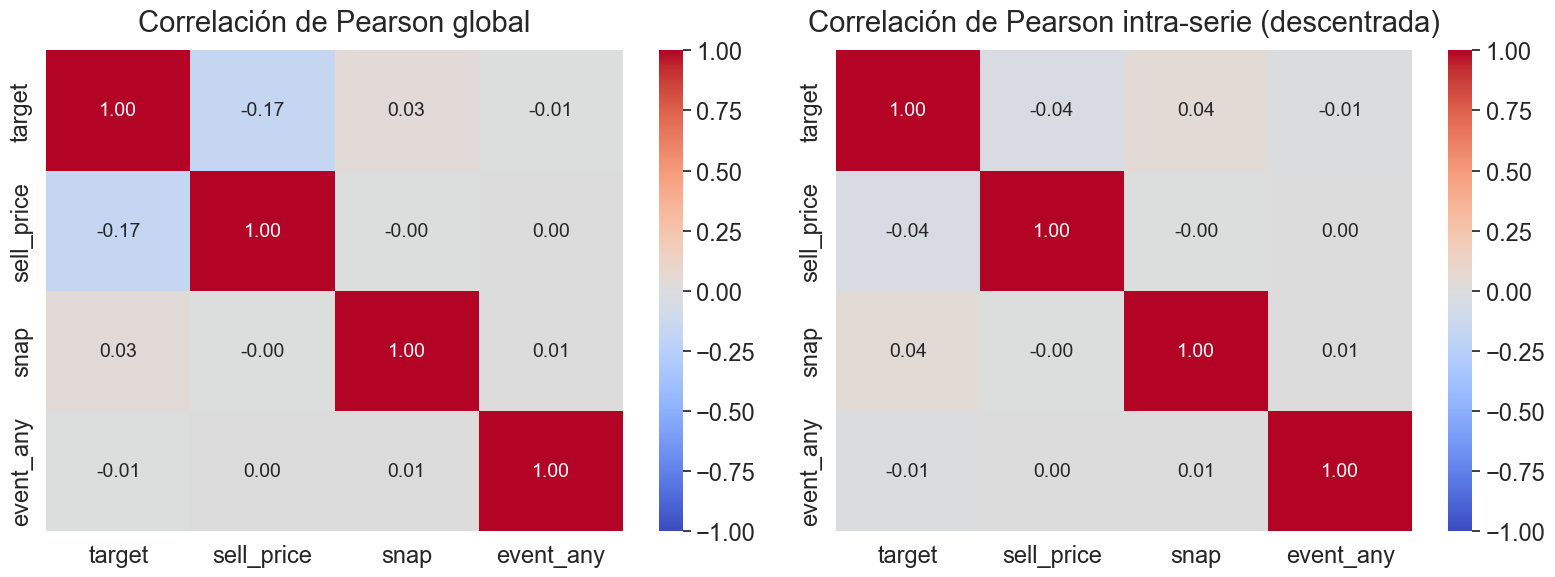

In [784]:
NUMERIC_COLS = CONTINUOUS + BINARY

df_demeaned = ctx[NUMERIC_COLS].sub(
    ctx.groupby('id')[NUMERIC_COLS].transform('mean')
)
corr_within = df_demeaned.corr()

with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1,
                annot_kws={'size': 14}, ax=axes[0])
    axes[0].set_title('Correlación de Pearson global')

    sns.heatmap(corr_within, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1,
                annot_kws={'size': 14}, ax=axes[1])
    axes[1].set_title('Correlación de Pearson intra-serie (descentrada)')

    plt.tight_layout()
    plt.show()

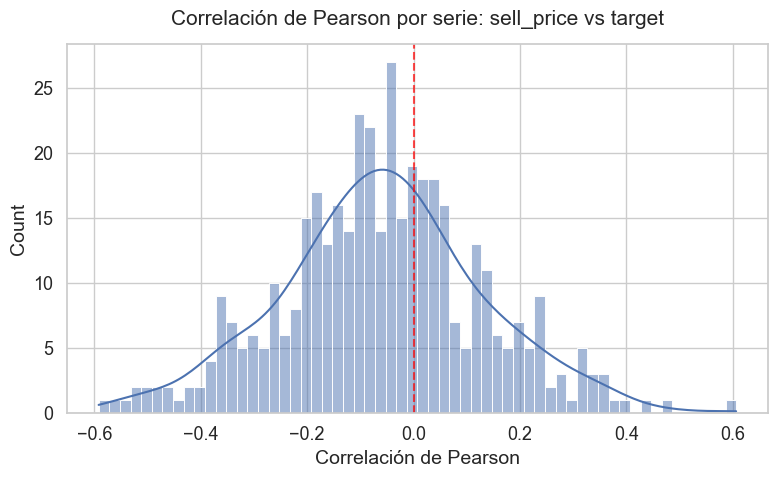

count    413.0000
mean      -0.0593
std        0.1912
min       -0.5920
25%       -0.1759
50%       -0.0616
75%        0.0504
max        0.6062
Name: corr_with_target, dtype: float64


In [785]:
# Per-series correlation of sell_price with target
# (sell_price can vary within a series over time)
per_series_price_corr = (
    ctx.dropna(subset=['sell_price'])
    .groupby('id')[['sell_price', TARGET]]
    .corr()
    .loc[:, TARGET]
    .reset_index()
    .rename(columns={'level_1': 'variable'})
    .query("variable == 'sell_price'")
    .rename(columns={TARGET: 'corr_with_target'})
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(per_series_price_corr['corr_with_target'].dropna(), bins=60, kde=True, ax=ax)
ax.axvline(0, color='red', linestyle='--', alpha=0.7)
ax.set_title('Correlación de Pearson por serie: sell_price vs target')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print(per_series_price_corr['corr_with_target'].describe().round(4))

### 9.2 Categorical variables vs `target`

For categorical features, Pearson correlation is not appropriate. We use:
- **Boxplots** to visualise how the target distribution shifts across categories.
- **Eta-squared (η²)** — ratio of between-group variance to total variance (analogous to R² from one-way ANOVA).

In [786]:
def eta_squared(df, categorical_col, continuous_col):
    """Compute eta-squared (ANOVA effect size) between a categorical and continuous variable."""
    groups = df.groupby(categorical_col)[continuous_col]
    grand_mean = df[continuous_col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for _, g in groups)
    ss_total = ((df[continuous_col] - grand_mean) ** 2).sum()
    return ss_between / ss_total if ss_total != 0 else 0.0

CATEGORICAL_FULL = ['wday', 'month', 'event_any', 'category', 'dept_id', 'state_id', 'store_id']

eta2_results = {col: eta_squared(ctx, col, TARGET) for col in CATEGORICAL_FULL}

eta2_df = pd.Series(eta2_results, name='eta_squared').sort_values(ascending=False)
print('Eta-squared (η²) — categorical features vs target:')
print(eta2_df.round(4))

Eta-squared (η²) — categorical features vs target:
dept_id      0.0168
store_id     0.0119
category     0.0098
wday         0.0053
state_id     0.0018
month        0.0003
event_any    0.0000
Name: eta_squared, dtype: float64


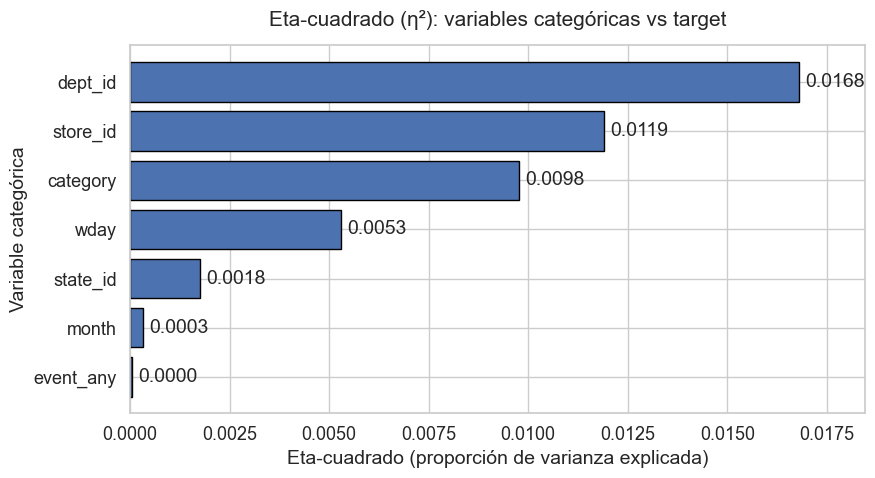

In [787]:
eta2_plot = eta2_df.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(eta2_plot.index, eta2_plot.values, edgecolor='black')
ax.set_title('Eta-cuadrado (η²): variables categóricas vs target')
ax.set_xlabel('Eta-cuadrado (proporción de varianza explicada)')
ax.set_ylabel('Variable categórica')
ax.set_xlim(0, max(eta2_plot.max() * 1.1, 0.01))

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + eta2_plot.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.4f}',
        va='center'
    )

plt.tight_layout()
plt.show()

In [788]:
# Eta-squared global vs within-series for categorical variables

def eta_squared_from_series(cat, y):
    """Eta-squared between a categorical variable and a continuous Series."""
    valid = cat.notna() & y.notna()
    cat_valid = cat[valid]
    y_valid = y[valid]
    grand_mean = y_valid.mean()
    ss_total = ((y_valid - grand_mean) ** 2).sum()
    if ss_total == 0:
        return 0.0
    ss_between = 0.0
    for _, group_idx in cat_valid.groupby(cat_valid).groups.items():
        group_y = y_valid.loc[group_idx]
        ss_between += len(group_y) * (group_y.mean() - grand_mean) ** 2
    return ss_between / ss_total


# Demean target by series id
ctx['target_within_series'] = (
    ctx[TARGET] - ctx.groupby('id')[TARGET].transform('mean')
)

eta2_global = {
    col: eta_squared_from_series(ctx[col], ctx[TARGET])
    for col in CATEGORICAL_FULL
}

eta2_within = {
    col: eta_squared_from_series(ctx[col], ctx['target_within_series'])
    for col in CATEGORICAL_FULL
}

eta2_comparison = pd.DataFrame({
    'eta2_global': eta2_global,
    'eta2_within_series': eta2_within
})
eta2_comparison['difference'] = (
    eta2_comparison['eta2_within_series'] - eta2_comparison['eta2_global']
)
eta2_comparison = eta2_comparison.sort_values('eta2_within_series', ascending=False)

display(eta2_comparison.round(4))

,eta2_global,eta2_within_series,difference
wday,0.0053,0.0092,0.0039
month,0.0003,0.0006,0.0002
event_any,0.0000,0.0001,0.0000
store_id,0.0119,0.0000,-0.0119
state_id,0.0018,0.0000,-0.0018
dept_id,0.0168,0.0000,-0.0168
category,0.0098,0.0000,-0.0098


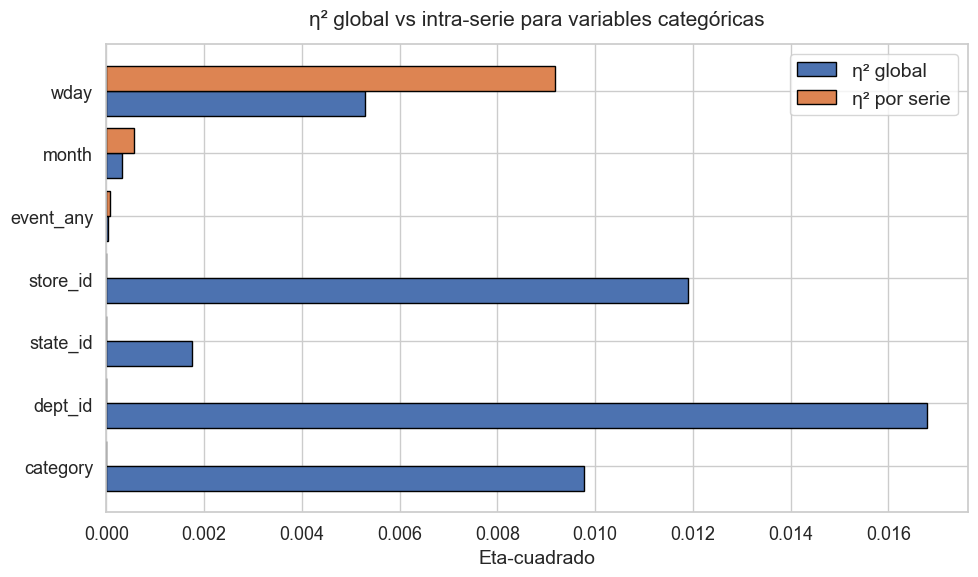

In [789]:
eta2_plot_cmp = eta2_comparison.sort_values('eta2_within_series', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(eta2_plot_cmp))

ax.barh(
    [y - 0.2 for y in y_pos],
    eta2_plot_cmp['eta2_global'],
    height=0.4,
    label='η² global',
    edgecolor='black'
)
ax.barh(
    [y + 0.2 for y in y_pos],
    eta2_plot_cmp['eta2_within_series'],
    height=0.4,
    label='η² por serie',
    edgecolor='black'
)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(eta2_plot_cmp.index)
ax.set_xlabel('Eta-cuadrado')
ax.set_title('η² global vs intra-serie para variables categóricas')
ax.legend()

plt.tight_layout()
plt.show()

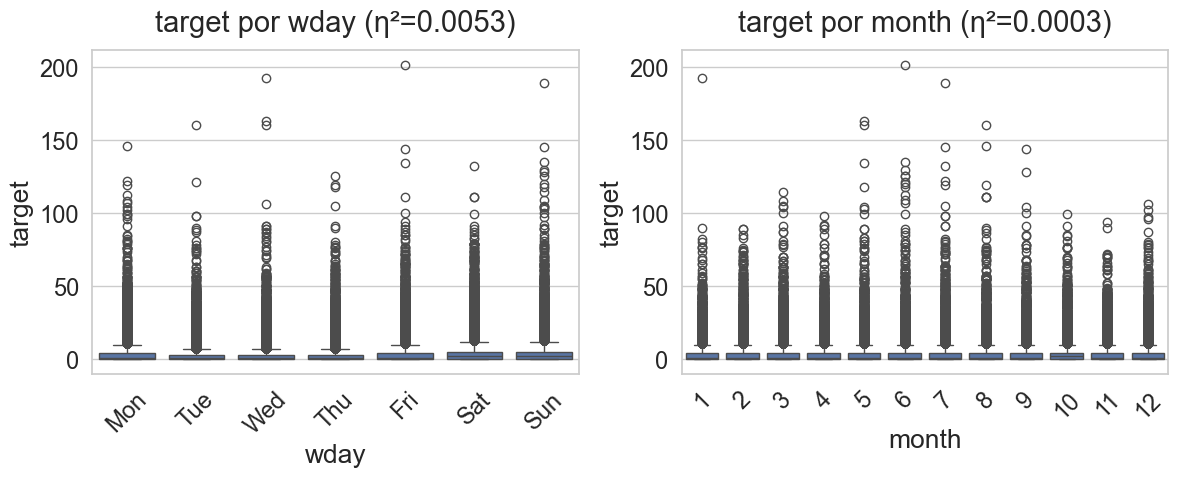

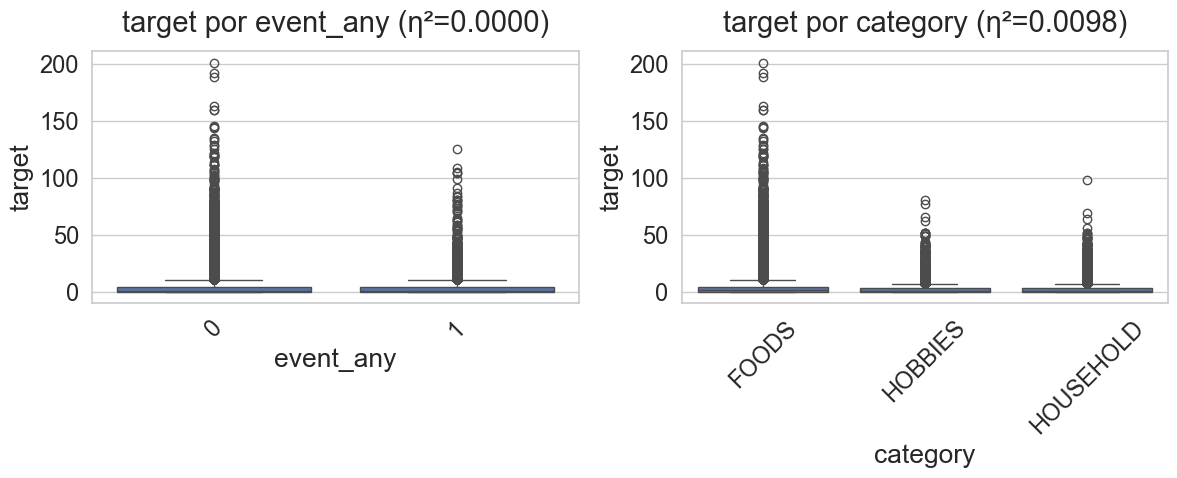

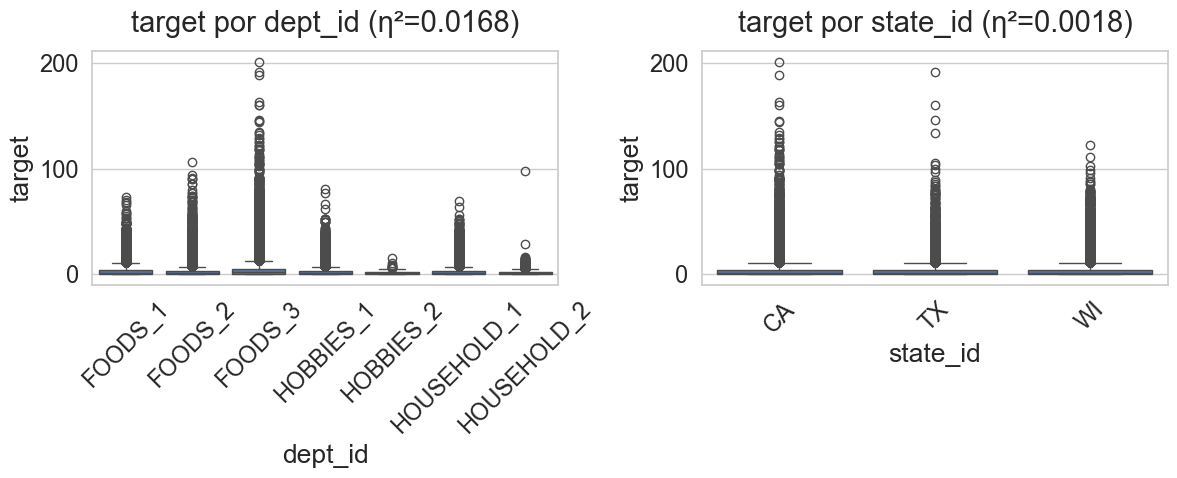

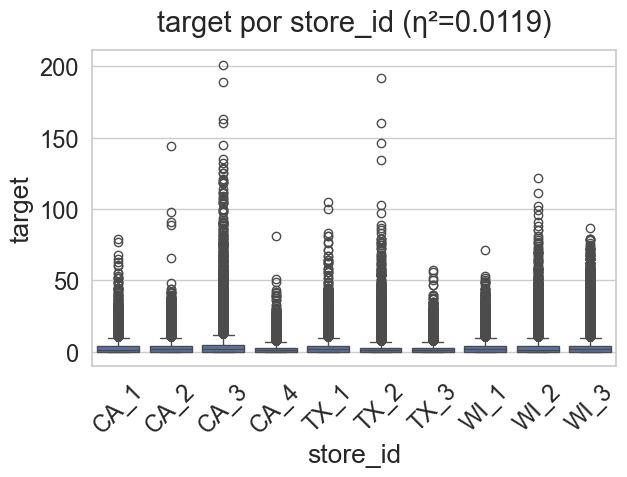

In [790]:
sample_n = min(200_000, len(ctx))
df_sample = ctx.sample(n=sample_n, random_state=42)

wday_to_iso = {3:1, 4:2, 5:3, 6:4, 7:5, 1:6, 2:7}
iso_labels  = {1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'}

def plot_boxrow(cols):
    with plt.rc_context(MULTI_RC):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for j, col in enumerate(cols):
            if col == 'wday':
                sample_wday = df_sample.assign(
                    wday_lbl=df_sample['wday'].map(wday_to_iso).map(iso_labels)
                )
                order_lbls = [iso_labels[k] for k in range(1, 8)]
                sns.boxplot(data=sample_wday, x='wday_lbl', y=TARGET, order=order_lbls, ax=axes[j])
                axes[j].set_title(f'target por wday (η²={eta2_results[col]:.4f})')
                axes[j].set_xlabel('wday')
            else:
                order = sorted(df_sample[col].dropna().unique())
                sns.boxplot(data=df_sample, x=col, y=TARGET, order=order, ax=axes[j])
                axes[j].set_title(f'target por {col} (η²={eta2_results[col]:.4f})')
            axes[j].tick_params(axis='x', rotation=45)
        if len(cols) == 1:
            axes[1].set_visible(False)
        plt.tight_layout()
        plt.show()

for i in range(0, len(CATEGORICAL_FULL), 2):
    plot_boxrow(CATEGORICAL_FULL[i:i+2])

## 10. Temporal patterns

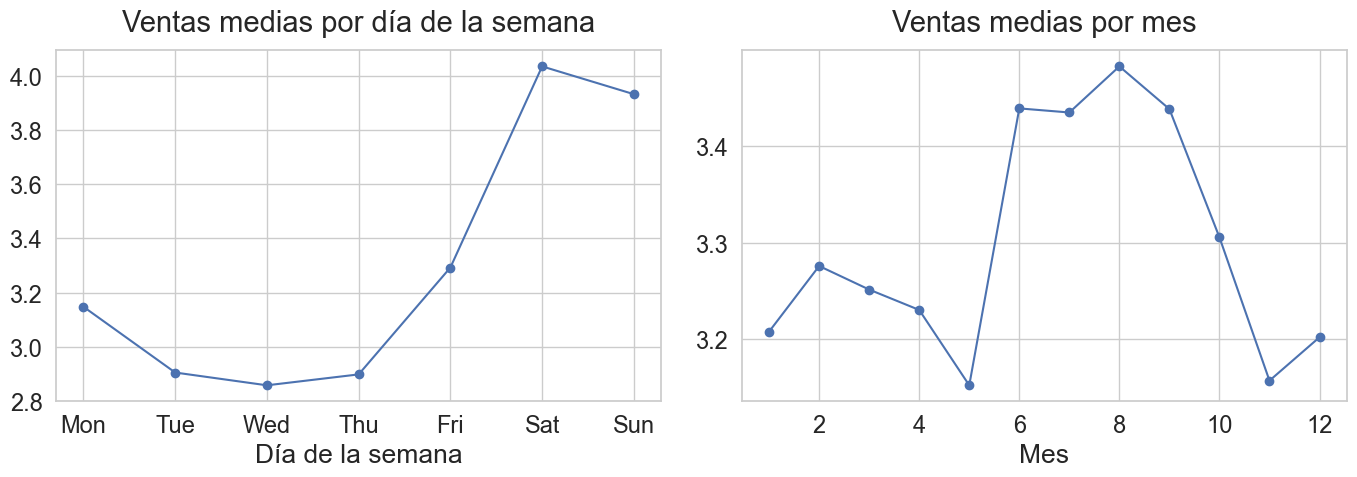

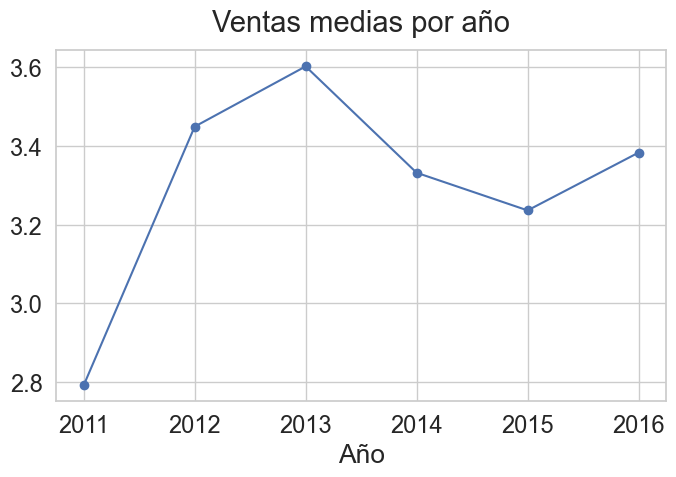

In [791]:
wday_to_iso = {3:1, 4:2, 5:3, 6:4, 7:5, 1:6, 2:7}
iso_labels  = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    dow_sales = (
        ctx.assign(iso_dow=ctx['wday'].map(wday_to_iso))
        .groupby('iso_dow')[TARGET].mean()
        .reindex(range(1, 8))
    )
    axes[0].plot(range(1, 8), dow_sales.values, marker='o')
    axes[0].set_xticks(range(1, 8))
    axes[0].set_xticklabels(iso_labels)
    axes[0].set_title('Ventas medias por día de la semana')
    axes[0].set_xlabel('Día de la semana')
    ctx.groupby('month')[TARGET].mean().plot(ax=axes[1], marker='o')
    axes[1].set_title('Ventas medias por mes')
    axes[1].set_xlabel('Mes')
    plt.tight_layout()
    plt.show()

with plt.rc_context(MULTI_RC):
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    ctx.assign(year=ctx['timestamp'].dt.year).groupby('year')[TARGET].mean().plot(ax=ax, marker='o')
    ax.set_title('Ventas medias por año')
    ax.set_xlabel('Año')
    plt.tight_layout()
    plt.show()

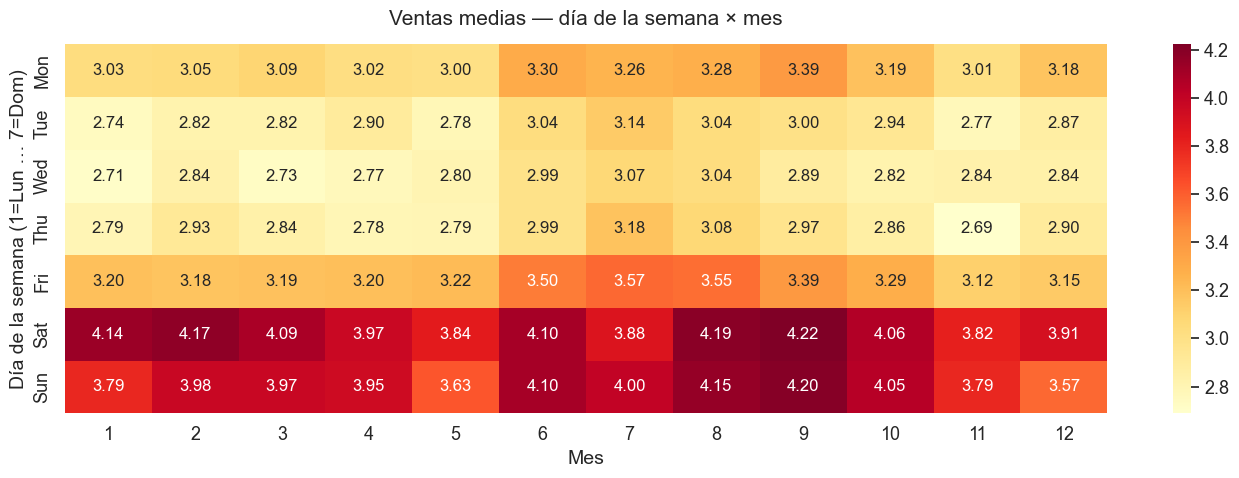

In [807]:
wday_to_iso = {3:1, 4:2, 5:3, 6:4, 7:5, 1:6, 2:7}
iso_labels  = {1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'}

pivot = (
    ctx.assign(iso_dow=ctx['wday'].map(wday_to_iso))
    .groupby(['iso_dow', 'month'])[TARGET].mean()
    .unstack()
)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.2f',
            yticklabels=[iso_labels[i] for i in pivot.index],
            annot_kws={'size': 12})
plt.title('Ventas medias — día de la semana × mes')
plt.ylabel('Día de la semana (1=Lun … 7=Dom)')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()

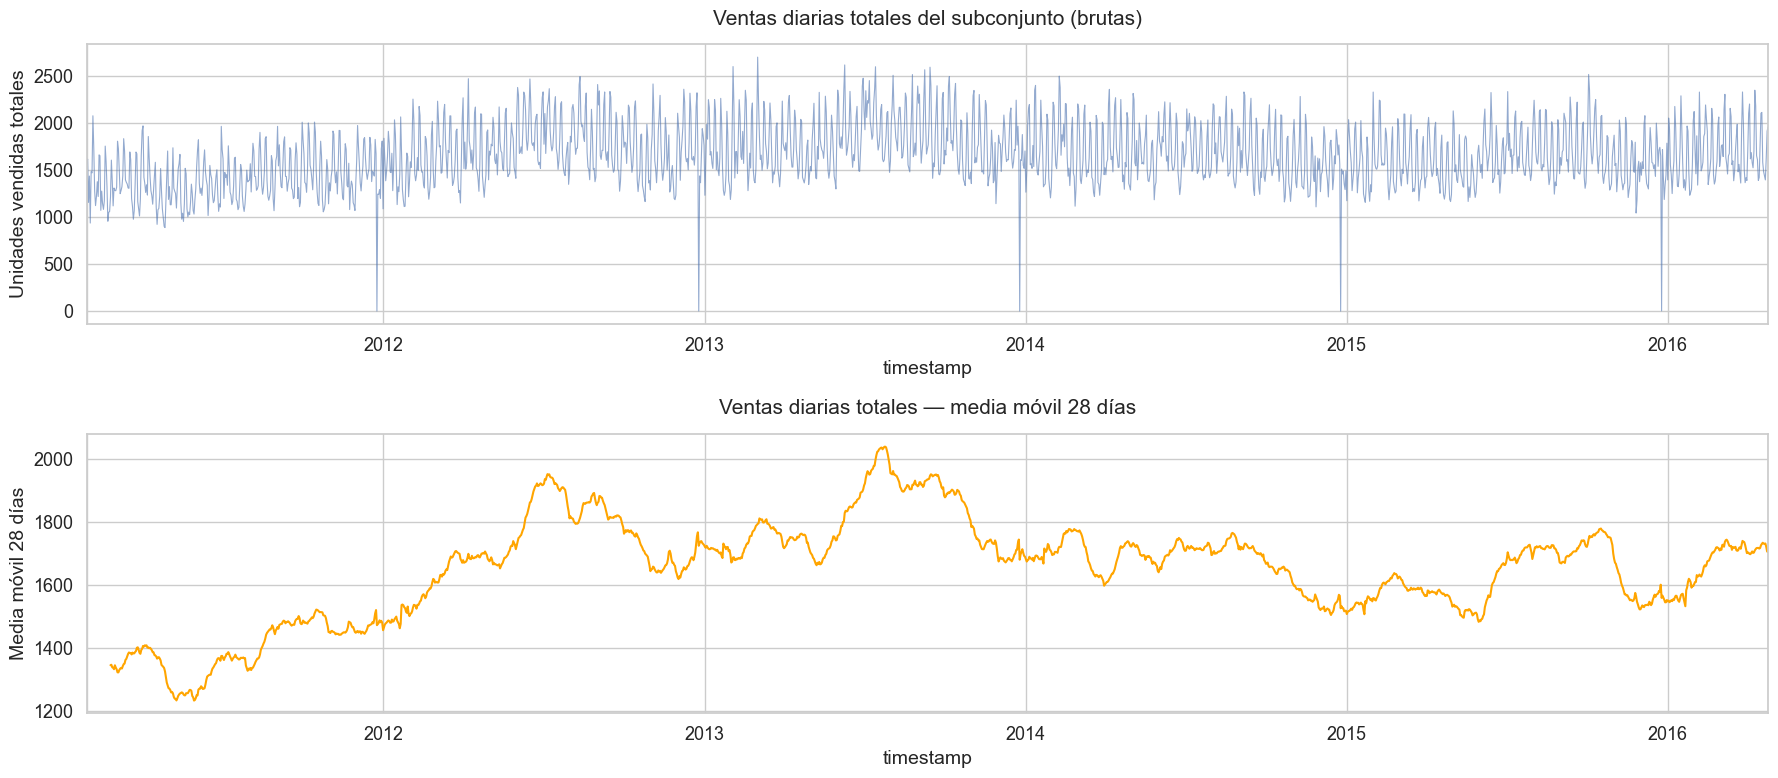

In [793]:
# Aggregated time series (sum of all series in subset) to spot macro trends
daily_total = ctx.groupby('timestamp')[TARGET].sum()

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=False)

daily_total.plot(ax=axes[0], alpha=0.6, linewidth=0.8)
axes[0].set_title('Ventas diarias totales del subconjunto (brutas)')
axes[0].set_ylabel('Unidades vendidas totales')

daily_total.rolling(28).mean().plot(ax=axes[1], color='orange', linewidth=1.5)
axes[1].set_title('Ventas diarias totales — media móvil 28 días')
axes[1].set_ylabel('Media móvil 28 días')

plt.tight_layout()
plt.show()

## 11. Event analysis

event_type_main value counts:
event_type_main
None         879500
Religious     26000
National      25500
Cultural      17500
Sporting       8000
Name: count, dtype: int64


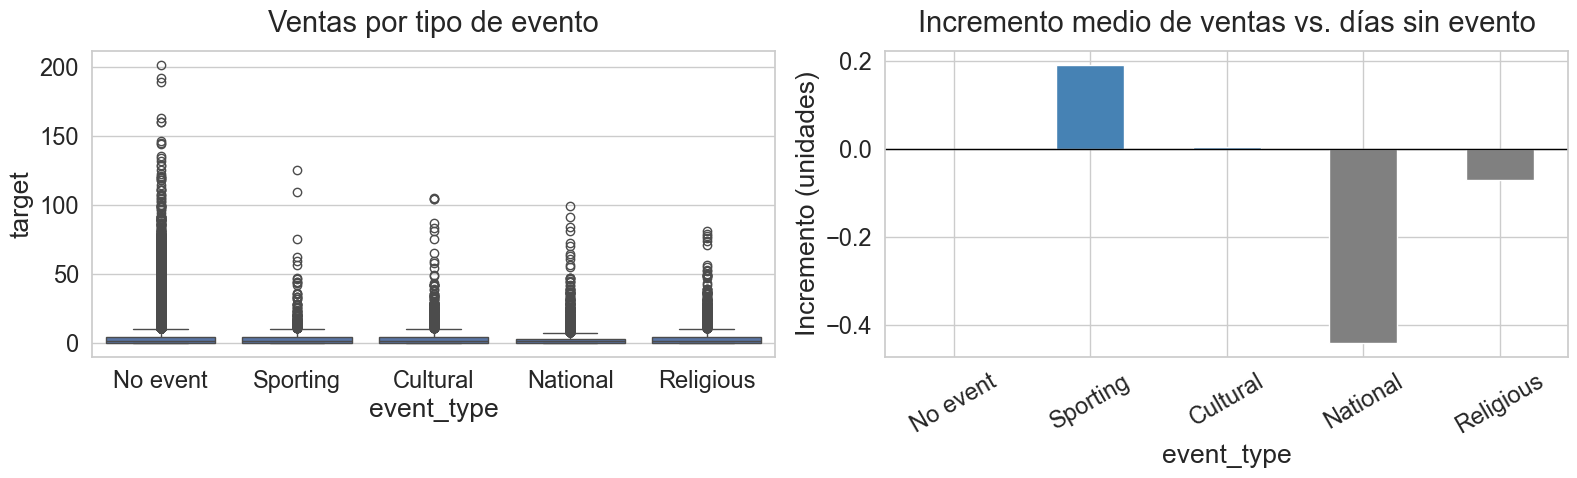

In [794]:
print('event_type_main value counts:')
print(ctx['event_type_main'].value_counts())

ctx_event = ctx.copy()
ctx_event['event_type'] = ctx_event['event_type_main'].replace('None', 'No event')

event_order = ['No event', 'Sporting', 'Cultural', 'National', 'Religious']
no_event_mean = ctx_event.loc[ctx_event['event_type'] == 'No event', TARGET].mean()
uplift = (
    ctx_event.groupby('event_type')[TARGET].mean()
    .reindex(event_order)
    .sub(no_event_mean)
    .rename('mean_sales_uplift')
)

with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.boxplot(data=df_sample.assign(event_type=df_sample['event_type_main'].replace('None', 'No event')),
                x='event_type', y=TARGET, order=event_order, ax=axes[0])
    axes[0].set_title('Ventas por tipo de evento')

    uplift.plot(kind='bar', ax=axes[1], color=['gray' if v < 0 else 'steelblue' for v in uplift])
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_title('Incremento medio de ventas vs. días sin evento')
    axes[1].set_ylabel('Incremento (unidades)')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

Mean sales — SNAP days vs non-SNAP days:
snap
0.0    3.151670
1.0    3.589749
Name: target, dtype: float64

SNAP uplift: +0.4381 units/day (13.90%)


/var/folders/jp/g9h79w4s2kvbjnyv8klyykqw0000gn/T/ipykernel_24862/2022513573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No SNAP', 'SNAP'])


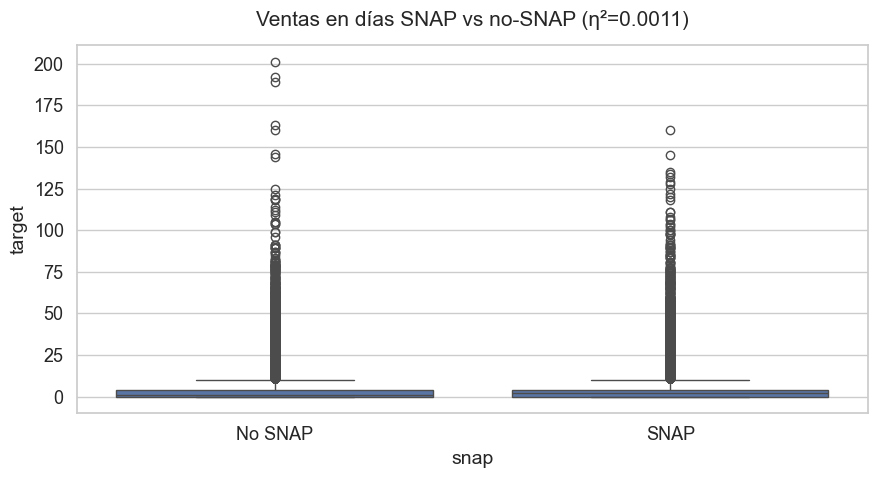

: 

In [ ]:
# SNAP (food-stamp acceptance days) effect
snap_mean = ctx.groupby('snap')[TARGET].mean()
print('Mean sales — SNAP days vs non-SNAP days:')
print(snap_mean)
print(f'\nSNAP uplift: +{snap_mean[1] - snap_mean[0]:.4f} units/day ({(snap_mean[1]/snap_mean[0]-1)*100:.2f}%)')

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_sample, x='snap', y=TARGET, ax=ax)
ax.set_xticklabels(['No SNAP', 'SNAP'])
ax.set_title(f'Ventas en días SNAP vs no-SNAP (η²={eta_squared(ctx, "snap", TARGET):.4f})')
plt.tight_layout()
plt.show()

## 12. Hierarchical analysis — by category, department, store, and state

In [796]:
# Number of series per group
print('Series per category:')
print(ctx.groupby('category')['id'].nunique())
print('\nSeries per store:')
print(ctx.groupby('store_id')['id'].nunique())
print('\nSeries per state:')
print(ctx.groupby('state_id')['id'].nunique())

Series per category:
category
FOODS        326
HOBBIES       32
HOUSEHOLD    142
Name: id, dtype: int64

Series per store:
store_id
CA_1    58
CA_2    49
CA_3    66
CA_4    45
TX_1    57
TX_2    52
TX_3    41
WI_1    40
WI_2    48
WI_3    44
Name: id, dtype: int64

Series per state:
state_id
CA    218
TX    150
WI    132
Name: id, dtype: int64


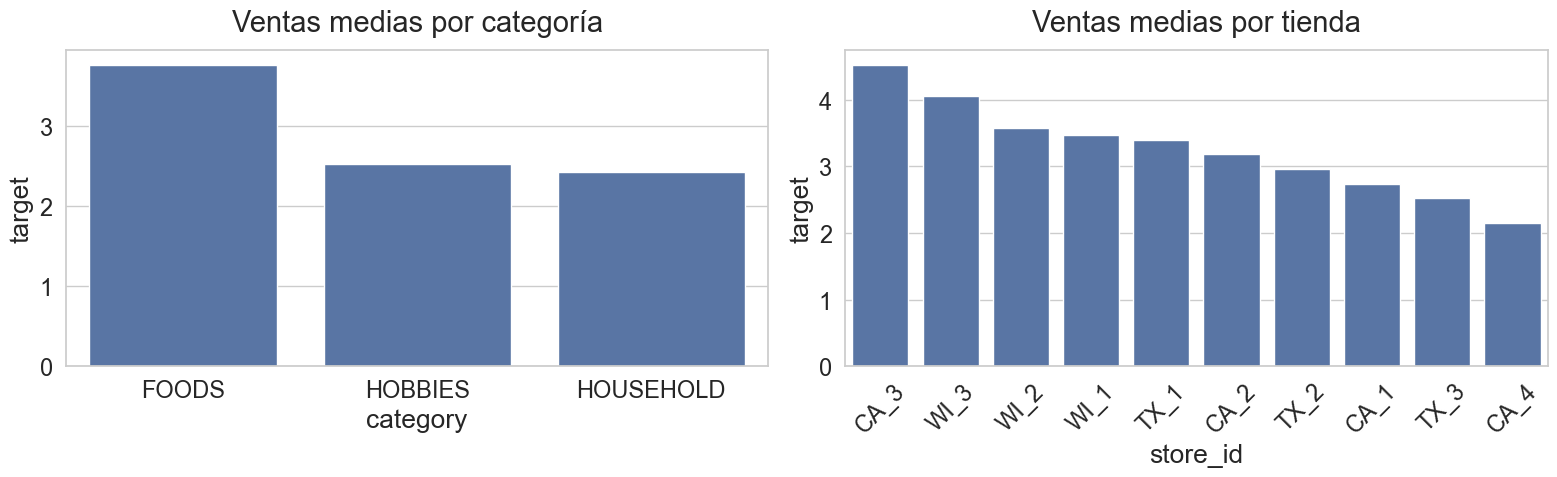

In [797]:
with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    cat_order = ctx.groupby('category')[TARGET].mean().sort_values(ascending=False).index.tolist()
    sns.barplot(data=ctx.groupby('category')[TARGET].mean().reset_index(),
                x='category', y=TARGET, order=cat_order, ax=axes[0])
    axes[0].set_title('Ventas medias por categoría')

    store_order = ctx.groupby('store_id')[TARGET].mean().sort_values(ascending=False).index.tolist()
    sns.barplot(data=ctx.groupby('store_id')[TARGET].mean().reset_index(),
                x='store_id', y=TARGET, order=store_order, ax=axes[1])
    axes[1].set_title('Ventas medias por tienda')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

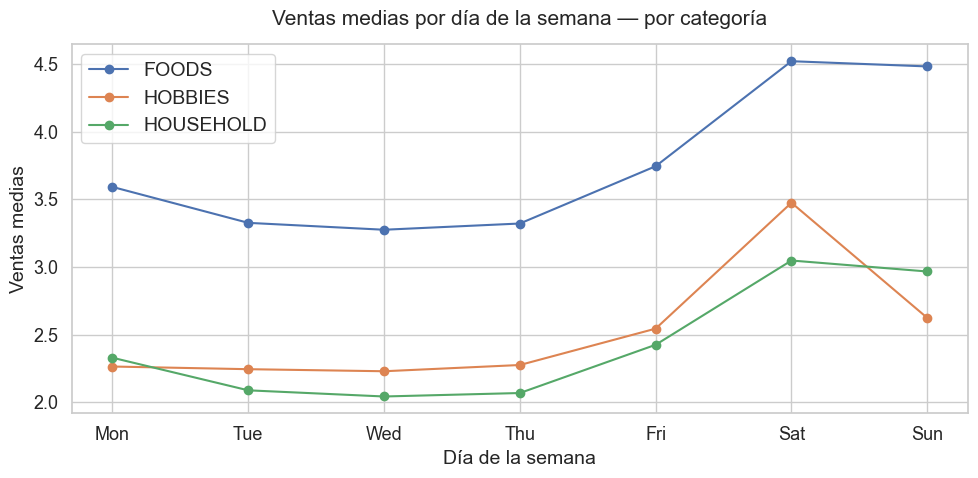

In [798]:
wday_to_iso = {3:1, 4:2, 5:3, 6:4, 7:5, 1:6, 2:7}
iso_labels  = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

weekly_by_cat = (
    ctx.assign(iso_dow=ctx['wday'].map(wday_to_iso))
    .groupby(['category', 'iso_dow'])[TARGET].mean()
    .unstack(level=0)
    .reindex(range(1, 8))
)

fig, ax = plt.subplots(figsize=(10, 5))
for cat in weekly_by_cat.columns:
    ax.plot(range(1, 8), weekly_by_cat[cat].values, marker='o', label=cat)
ax.set_xticks(range(1, 8))
ax.set_xticklabels(iso_labels)
ax.set_title('Ventas medias por día de la semana — por categoría')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Ventas medias')
ax.legend()
plt.tight_layout()
plt.show()

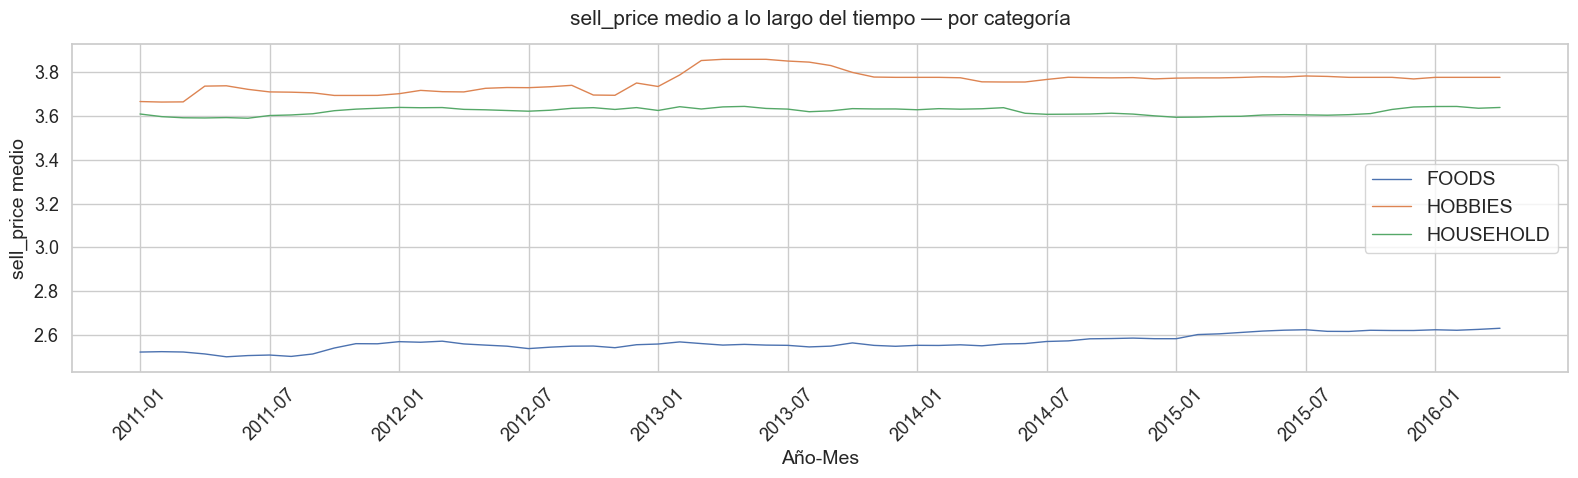

In [799]:
price_by_month = (
    ctx.dropna(subset=['sell_price'])
    .assign(year_month=lambda d: d['timestamp'].dt.to_period('M'))
    .groupby(['year_month', 'category'])['sell_price']
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(16, 5))
for cat in price_by_month.columns:
    ax.plot(price_by_month.index.astype(str), price_by_month[cat], label=cat, linewidth=1)
ax.set_title('sell_price medio a lo largo del tiempo — por categoría')
ax.set_xlabel('Año-Mes')
ax.set_ylabel('sell_price medio')
ax.legend()
ax.tick_params(axis='x', rotation=45)
# Reduce x-tick density
ticks = ax.get_xticks()
ax.set_xticks(ticks[::6])
plt.tight_layout()
plt.show()

## 13. Holdout split overview

The holdout uses two files:
- **`m5_future.csv`**: 28-day feature window (no `target`) — fed to the model at inference time.
- **`m5_actuals.csv`**: 28-day ground truth — used only for evaluation.

In [800]:
# Basic checks
print('=== m5_future.csv (subset) ===')
print(fut.dtypes)
print(f'Rows: {fut.shape[0]:,}  |  Series: {fut["id"].nunique():,}')
print(f'Date range: {fut["timestamp"].min().date()} → {fut["timestamp"].max().date()}')
print(f'Horizon length: {fut["timestamp"].nunique()} days')
print(f'Nulls: {fut.isnull().sum().to_dict()}')
print()
print('=== m5_actuals.csv (subset) ===')
print(f'Rows: {act.shape[0]:,}  |  Series: {act["id"].nunique():,}')
print(f'Date range: {act["timestamp"].min().date()} → {act["timestamp"].max().date()}')
print(f'Nulls: {act.isnull().sum().to_dict()}')

# Verify perfect alignment
fut_keys = set(zip(fut['id'], fut['timestamp']))
act_keys = set(zip(act['id'], act['timestamp']))
print(f'\nfuture / actuals key overlap: {len(fut_keys & act_keys):,} (expected {len(fut_keys):,})')

=== m5_future.csv (subset) ===
id                         object
timestamp          datetime64[ns]
sell_price                float64
snap                      float64
wday                        int64
month                       int64
event_any                   int64
event_type_main            object
dtype: object
Rows: 14,000  |  Series: 500
Date range: 2016-04-25 → 2016-05-22
Horizon length: 28 days
Nulls: {'id': 0, 'timestamp': 0, 'sell_price': 0, 'snap': 0, 'wday': 0, 'month': 0, 'event_any': 0, 'event_type_main': 0}

=== m5_actuals.csv (subset) ===
Rows: 14,000  |  Series: 500
Date range: 2016-04-25 → 2016-05-22
Nulls: {'id': 0, 'timestamp': 0, 'target': 0}

future / actuals key overlap: 14,000 (expected 14,000)


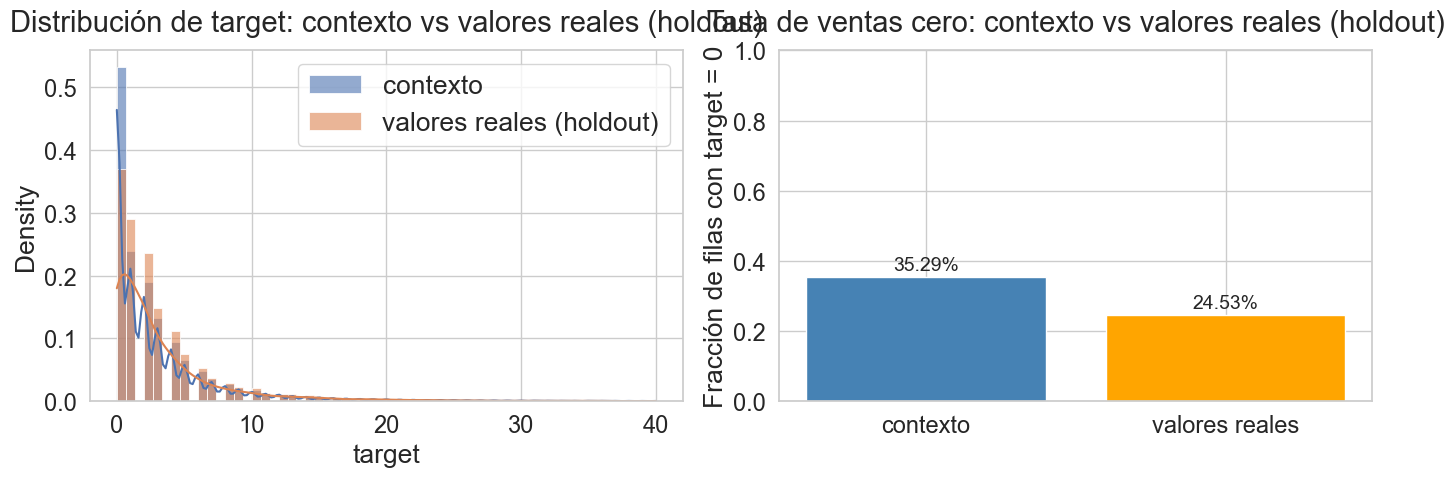

In [801]:
clip_ctx = ctx[TARGET].quantile(0.995)
clip_act = act[TARGET].quantile(0.995)
clip_val = max(clip_ctx, clip_act)

zero_ctx  = (ctx[TARGET] == 0).mean()
zero_act  = (act[TARGET] == 0).mean()

with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(ctx.loc[ctx[TARGET] <= clip_val, TARGET], bins=60, kde=True, ax=axes[0],
                 label='contexto', stat='density', alpha=0.6)
    sns.histplot(act.loc[act[TARGET] <= clip_val, TARGET], bins=60, kde=True, ax=axes[0],
                 label='valores reales (holdout)', stat='density', alpha=0.6)
    axes[0].set_title('Distribución de target: contexto vs valores reales (holdout)')
    axes[0].legend()

    axes[1].bar(['contexto', 'valores reales'], [zero_ctx, zero_act], color=['steelblue', 'orange'])
    axes[1].set_title('Tasa de ventas cero: contexto vs valores reales (holdout)')
    axes[1].set_ylabel('Fracción de filas con target = 0')
    axes[1].set_ylim(0, 1)
    for bar, val in zip(axes[1].patches, [zero_ctx, zero_act]):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2%}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

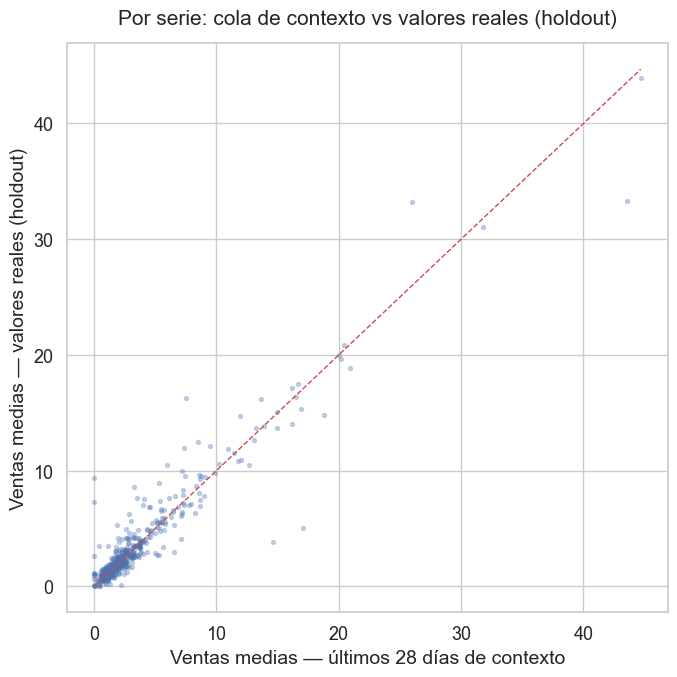

Pearson r (context tail vs actuals): 0.9466


In [802]:
CONTEXT_TAIL_DAYS = 28
ctx_tail_date = ctx['timestamp'].max() - pd.Timedelta(days=CONTEXT_TAIL_DAYS - 1)

ctx_tail_mean = (
    ctx.loc[ctx['timestamp'] >= ctx_tail_date]
    .groupby('id')[TARGET].mean()
    .rename('ctx_tail_mean')
)
act_mean = act.groupby('id')[TARGET].mean().rename('act_mean')

compare = pd.concat([ctx_tail_mean, act_mean], axis=1).dropna()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(compare['ctx_tail_mean'], compare['act_mean'], alpha=0.3, s=8)
lim = max(compare.max().max(), 1)
ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
ax.set_xlabel('Ventas medias — últimos 28 días de contexto')
ax.set_ylabel('Ventas medias — valores reales (holdout)')
ax.set_title('Por serie: cola de contexto vs valores reales (holdout)')
plt.tight_layout()
plt.show()

corr_val = compare.corr().loc['ctx_tail_mean', 'act_mean']
print(f'Pearson r (context tail vs actuals): {corr_val:.4f}')

## 14. Pairplot — target + most relevant features

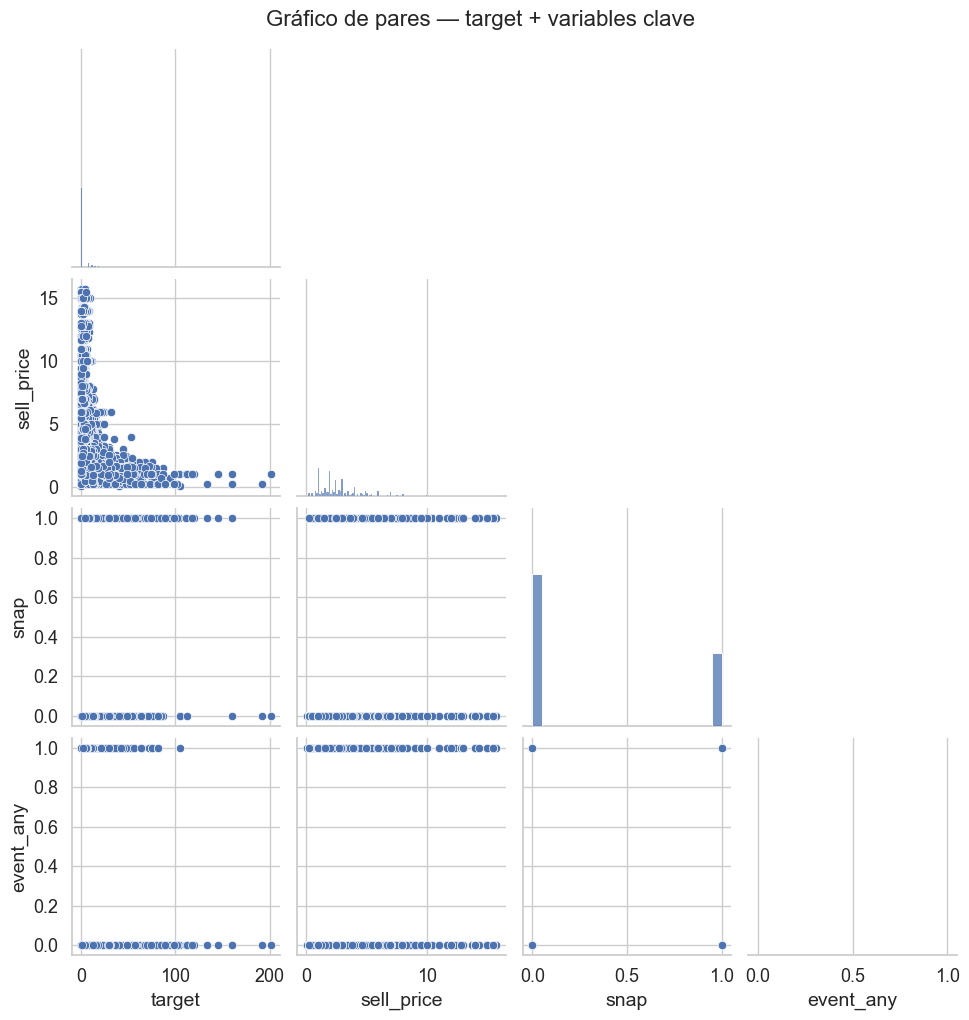

In [803]:
pairplot_cols = ['target', 'sell_price', 'snap', 'event_any']
pp_n = min(50_000, len(ctx[pairplot_cols].dropna()))
sample_pp = ctx[pairplot_cols].dropna().sample(n=pp_n, random_state=42)

sns.pairplot(sample_pp, corner=True)
plt.suptitle('Gráfico de pares — target + variables clave', y=1.02)
plt.show()

## 15. Conclusiones

Tras el análisis exploratorio realizado sobre el **subconjunto experimental de 500 series densas** del dataset M5 (956.500 registros de contexto, periodo 2011-01-29 → 2016-04-24), se extraen las siguientes conclusiones:

### Subconjunto seleccionado

El subconjunto utiliza la estrategia `dense_random` (percentil 75 de `nonzero_ratio`, seed=42), idéntica a los notebooks de Chronos-2 y TimeXer. Las 500 series seleccionadas tienen una mediana de `nonzero_ratio` superior al dataset completo, lo que refleja que los experimentos se realizan sobre series con demanda más continua — reduciendo el efecto de la demanda altamente intermitente en la evaluación.

### Calidad de los datos y preprocesamiento

- El campo `target` **no contiene valores nulos** en el subconjunto.
- `sell_price` presenta ~5.9% de valores nulos antes de la imputación. Tras aplicar `fill_sell_price` (ffill/bfill por serie → mediana por serie → mediana global), **no quedan valores nulos** — idéntico al tratamiento de los notebooks de experimentos.
- `event_type_main` es nulo en días sin evento — comportamiento esperado, no se imputa.
- El holdout está perfectamente alineado: 14.000 filas en `fut` y `act` (500 series × 28 días).

### Naturaleza de la variable objetivo

- Aun en el subconjunto denso, la distribución de `target` presenta **sesgo a la derecha** con masa significativa en cero (demanda intermitente).
- Al ser series con `nonzero_ratio ≥ percentil 75`, la tasa de ceros es **inferior** a la del dataset completo (~68% global), mejorando la estimabilidad de los modelos.

### Patrones temporales

- Se mantiene la **estacionalidad semanal** (sábados y domingos con mayor demanda).
- La **tendencia anual** de crecimiento se conserva en el subconjunto.
- El heatmap día-de-semana × mes muestra los mismos patrones estables que el dataset completo.

### Variables exógenas

- **`snap`** conserva el uplift positivo sobre ventas, especialmente en FOODS.
- **`event_any`** y el tipo de evento muestran un efecto similar al observado en el dataset completo.
- **`sell_price`** mantiene correlación negativa débil a nivel global; la distribución within-series muestra heterogeneidad similar.

### Jerarquía

- El subconjunto puede estar sesgado hacia ciertas categorías/tiendas con mayor densidad de ventas; los `η²` por categoría y tienda deben interpretarse en este contexto.
- Las series FOODS_3 (categoría de mayor volumen) están sobrerrepresentadas en las series más densas.

### Representatividad del holdout

- La distribución de `target` en el holdout (actuals) es muy similar a la ventana de contexto.
- La correlación per-serie entre la media de los últimos 28 días de contexto y la media de los actuals es alta, confirmando que el holdout es representativo del comportamiento reciente del subconjunto.